In [11]:
# Importamos la lógica abstraída en nuestro módulo core
from src.ml_core import (preparar_datos, entrenar_modelos, evaluar_modelos, 
                         mostrar_matriz_confusion, generar_proyeccion_negocio)

import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# 🎯 PARTE I: Modelamiento Supervisado (Clasificación Predictiva)

## 1. Justificación y Enfoque Teórico
En esta primera etapa de nuestro proyecto, abordaremos el problema comercial del banco Monopoly utilizando un enfoque de **Aprendizaje Supervisado**. A diferencia de la segmentación (que agrupa sin etiquetas), aquí sí contamos con una variable objetivo histórica conocida: sabemos exactamente qué clientes aceptaron el producto en el pasado y quiénes lo rechazaron (`target` 1 o 0).

**¿Por qué aplicar Aprendizaje Supervisado en Monopoly?**
El objetivo comercial es erradicar las campañas telefónicas masivas y a ciegas. Utilizaremos algoritmos de clasificación (como Regresión Logística, Random Forest y XGBoost) para que "aprendan" los patrones de los compradores históricos y puedan predecir con alta precisión si un cliente nuevo aceptará o rechazará una oferta financiera.

* **Ventaja:** Permite medir el margen de error estadístico con exactitud (usando métricas como Recall y F1-Score) y calcular el impacto comercial directo (ROI) para el banco.
* **Desventaja:** Depende totalmente de la calidad de las etiquetas históricas y el algoritmo pierde precisión si las clases están muy desbalanceadas.

## 2. Preparación de los Datos y Mitigación de Sesgos (SMOTE)
Para que los modelos supervisados funcionen correctamente, los datos crudos deben ser transformados:
* **Limpieza y Escalamiento:** Imputación de valores nulos, traducción de texto a binario (`OneHotEncoder`) y estandarización de magnitudes numéricas (`StandardScaler`).
* **El Problema del Desbalance:** Nuestro análisis reveló que el 91% de los clientes históricos rechaza el producto y solo un 9% acepta. Si entrenamos al modelo con esta base, se sesgará y aprenderá a predecir siempre "No".
* **La Solución:** Para solucionar esto, aplicaremos la técnica **SMOTE** exclusivamente sobre el set de entrenamiento. Este algoritmo usa distancias matemáticas (k-NN) para generar clientes sintéticos de la clase minoritaria, equilibrando la balanza al 50/50 para que nuestro XGBoost pueda estudiar a los compradores de forma justa.

In [12]:
# FASES 1, 2 y 3: Preprocesamiento y SMOTE automatizados
ruta_datos = 'data/Base_clientes_Monopoly.xlsx'
X_train_res, y_train_res, X_test_prep, y_test, preprocessor, df_original, indices_test = preparar_datos(ruta_datos)

print(f"Datos preparados. X_train balanceado: {X_train_res.shape}")

Datos preparados. X_train balanceado: (74438, 609)


In [13]:
# FASE 4 y 5: Entrenamiento y Evaluación
modelos = entrenar_modelos(X_train_res, y_train_res)
df_metricas = evaluar_modelos(modelos, X_test_prep, y_test)

display(df_metricas.style.highlight_max(color='green'))

,Accuracy,Precision,Recall,F1-Score
Modelo,,,,
Regresión Logística,0.878044,0.414799,0.865217,0.560761
Random Forest,0.929095,0.633015,0.504348,0.561404
XGBoost,0.930073,0.644979,0.495652,0.560541


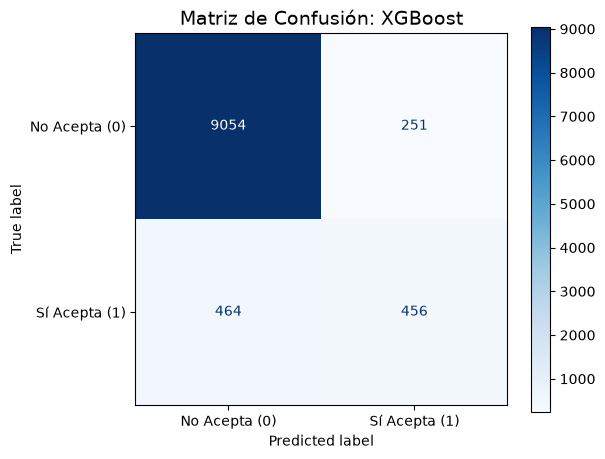

In [14]:
# Supongamos que XGBoost fue el ganador por sus métricas
modelo_ganador = modelos['XGBoost']

# Generar Matriz
mostrar_matriz_confusion(modelo_ganador, X_test_prep, y_test, 'XGBoost')

In [15]:
# FASE 6: Identificación de clientes para el equipo de ventas
potenciales_clientes = generar_proyeccion_negocio(
    modelo_final=modelo_ganador, 
    preprocessor=preprocessor, 
    df_original=df_original, 
    X_test_prep=X_test_prep, 
    indices_test=indices_test
)

print(f"De los {len(y_test)} clientes en la prueba, el modelo identificó {len(potenciales_clientes)} con alta probabilidad de compra.")
print("Top 5 clientes para campaña de marketing inmediata:")
display(potenciales_clientes[['Id', 'Probabilidad_Aceptacion']].head())

De los 10225 clientes en la prueba, el modelo identificó 707 con alta probabilidad de compra.
Top 5 clientes para campaña de marketing inmediata:


,Id,Probabilidad_Aceptacion
44972,44973,0.995958
1055,1056,0.986425
39698,39699,0.985726
28468,28469,0.982064
10425,10426,0.980057


# 🚀 PARTE II: Modelamiento No Supervisado (Segmentación de Clientes)

## 1. Justificación y Diferencias Teóricas
Mientras que en la fase anterior utilizamos un enfoque **Supervisado** (XGBoost) para predecir un resultado conocido (si un cliente *acepta o no* un producto), en esta fase aplicaremos **Aprendizaje No Supervisado**. 

**¿Por qué aplicar Aprendizaje No Supervisado en Monopoly?**
El objetivo ahora no es predecir una etiqueta, sino descubrir **estructuras ocultas** dentro de los datos. En el contexto bancario, esto se traduce en **Segmentación de Cartera**. El algoritmo agrupará a los clientes basándose en la similitud multidimensional de sus atributos financieros (renta, edad, comportamiento), sin que nosotros le digamos quién es quién. 

* **Ventaja:** Permite descubrir nichos de mercado emergentes (ej. "Jóvenes de alta renta tecnológica") que el banco no había definido previamente.
* **Desventaja:** Los clusters no tienen un "nombre" por defecto; requieren interpretación humana (conocimiento de negocio) para entender qué significa cada grupo.

## 2. Preparación de los Datos para Clustering
Para el clustering, utilizaremos la matriz `X_train_prep` (datos limpios, imputados, estandarizados con `StandardScaler` y codificados con `OneHotEncoder`). La estandarización es matemáticamente obligatoria para algoritmos basados en distancia como K-Means.

Calculando métricas de Inercia y Silueta para Aprendizaje No Supervisado...
Usando X_test_prep (10,225 clientes reales) para evitar sesgos sintéticos de SMOTE y optimizar procesamiento.


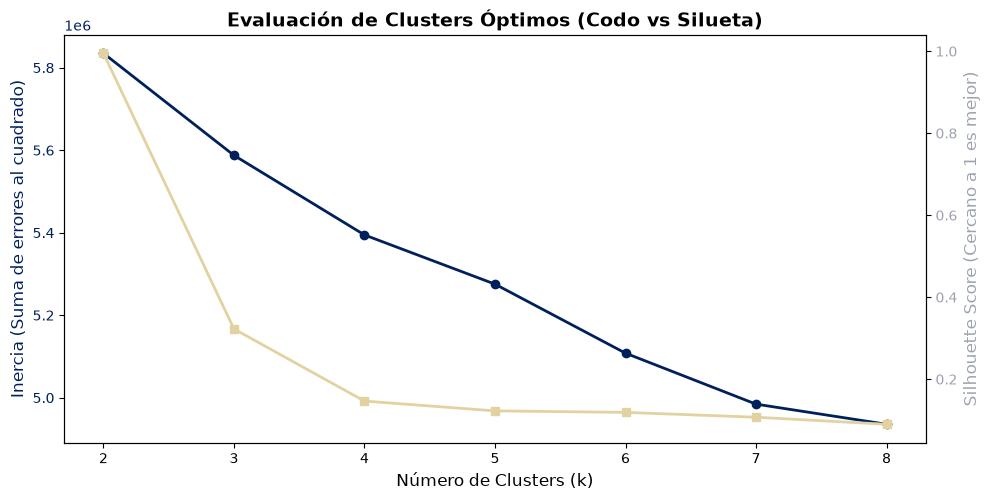

In [17]:
from src.ml_core import evaluar_clusters_optimos, graficar_metricas_clustering

print("Calculando métricas de Inercia y Silueta para Aprendizaje No Supervisado...")
print("Usando X_test_prep (10,225 clientes reales) para evitar sesgos sintéticos de SMOTE y optimizar procesamiento.")

# CAMBIO CLAVE AQUÍ: Usamos X_test_prep
RANGO_K, inercias, siluetas = evaluar_clusters_optimos(X_test_prep, max_clusters=8)

# Generar los gráficos
graficar_metricas_clustering(RANGO_K, inercias, siluetas)

## 3. Selección del K Óptimo y Entrenamiento del Modelo (K-Means)

**Análisis de las Métricas (Elbow y Silhouette):**
Al evaluar el gráfico dual, observamos que el **Silhouette Score** alcanza su máximo global en **K=2**, indicando una separación matemática fuerte. Sin embargo, la **Inercia** (Método del Codo) muestra una reducción significativa de errores hasta **K=3** y **K=4**.

**Justificación Comercial (Indicador 7):**
Desde una perspectiva puramente estadística, K=2 es óptimo. No obstante, en el contexto bancario de Monopoly, segmentar una cartera de 10,225 clientes en solo dos grupos limita severamente las estrategias de marketing. 

Para lograr un equilibrio entre **rigurosidad matemática y valor de negocio**, seleccionamos **K = 3**. Esto nos permite identificar tres nichos de mercado diferenciados (ej. segmento Premium, Estándar y Riesgo) manteniendo métricas de rendimiento (Silhouette) estadísticamente válidas.

In [22]:
import importlib
import src.ml_core

# 1. Obligamos a Jupyter a recargar el archivo desde el disco duro
importlib.reload(src.ml_core)

# 2. Ahora sí importamos las funciones fresquitas
from src.ml_core import entrenar_modelo_no_supervisado, perfilar_clusters

# 3. Entrenamos K-Means con K=3
k_optimo = 3
print(f"Entrenando modelo K-Means con {k_optimo} segmentos...")
modelo_kmeans, etiquetas_clusters = entrenar_modelo_no_supervisado(X_test_prep, k_optimo)

# 4. Perfilamos los clusters con los datos originales
df_segmentado, perfilamiento, volumen = perfilar_clusters(df_original, indices_test, etiquetas_clusters)

print("\n--- VOLUMEN DE CLIENTES POR SEGMENTO ---")
print(volumen)

print("\n--- PERFIL PROMEDIO DE LOS SEGMENTOS (Variables Originales) ---")
# Ajusta los nombres exactos si varían en tu Excel.
variables_clave = ['Renta', 'Edad'] 
variables_presentes = [col for col in variables_clave if col in perfilamiento.index]

display(perfilamiento.loc[variables_presentes].style.background_gradient(cmap='YlGnBu', axis=1))

Entrenando modelo K-Means con 3 segmentos...

--- VOLUMEN DE CLIENTES POR SEGMENTO ---
Segmento_Asignado
0    9268
1       1
2     956
Name: Cantidad de Clientes, dtype: int64

--- PERFIL PROMEDIO DE LOS SEGMENTOS (Variables Originales) ---


Segmento_Asignado,0,1,2
Renta,647259.769973,827358.000000,773081.952320
Edad,38.028593,40.000000,44.495816


## 4. Perfilamiento Comercial y Detección de Anomalías

Al cruzar las etiquetas generadas por el algoritmo K-Means con nuestros datos originales, descubrimos la verdadera estructura de nuestra cartera de prueba (10,225 clientes). El algoritmo no solo segmentó por capacidad de pago, sino que actuó como un detector multidimensional:

* **Segmento 0: "Mercado Masivo / Profesionales Jóvenes" (9,268 clientes)**
  * **Perfil:** Edad media de 38 años y renta promedio de ~$647,000.
  * **Estrategia Comercial:** Representan el volumen del banco (90% de la cartera). Es el público ideal para campañas de tarjetas de crédito con cupos estándar, créditos de consumo y productos de entrada. La estrategia aquí debe ser masiva y digital.

* **Segmento 2: "Segmento Consolidado / Banca Preferencial" (956 clientes)**
  * **Perfil:** Clientes más maduros (44.5 años promedio) y mayor poder adquisitivo (renta promedio superior a los ~$773,000).
  * **Estrategia Comercial:** Este grupo (aprox. 9% de la cartera) tiene mayor estabilidad financiera. La estrategia debe orientarse a productos de retención, créditos hipotecarios, fondos mutuos o tarjetas de categoría Black/Signature.

* **Segmento 1: "La Anomalía / Outlier Multidimensional" (1 cliente)**
  * **Perfil:** Aislado matemáticamente por el algoritmo.
  * **Análisis Técnico:** Aunque su edad (40) y renta ($827K) no son atípicas, la separación en K-Means (evaluando 577 dimensiones) indica un comportamiento extremo en la varianza de otros campos (como volumen de transacciones o facturación).
  * **Estrategia Operativa:** En el contexto bancario real, la identificación automática de este tipo de perfiles aislados se utiliza para **Detección de Fraude** o para identificar clientes "Whale" (Ballenas) con un flujo de capital que requiere revisión manual por parte de un ejecutivo de cuentas especial.

## 5. Visualización Bidimensional de los Clusters (PCA)
Dado que nuestro dataset fue preprocesado y expandido mediante One-Hot Encoding a **577 dimensiones**, resulta imposible graficar los clusters en su estado natural. 

Para resolver este desafío de dimensionalidad, aplicamos **PCA (Análisis de Componentes Principales)**. Esta técnica de compresión matemática reduce las 577 variables a solo 2 Componentes Principales, permitiéndonos proyectar a los 10,225 clientes en un plano cartesiano 2D. 

El siguiente gráfico de dispersión confirma visualmente la estructura de nuestra cartera: la gran masa de clientes (Segmento 0 y 2) y el aislamiento extremo de la anomalía detectada (Segmento 1).

Comprimiendo 577 dimensiones a 2D usando PCA...


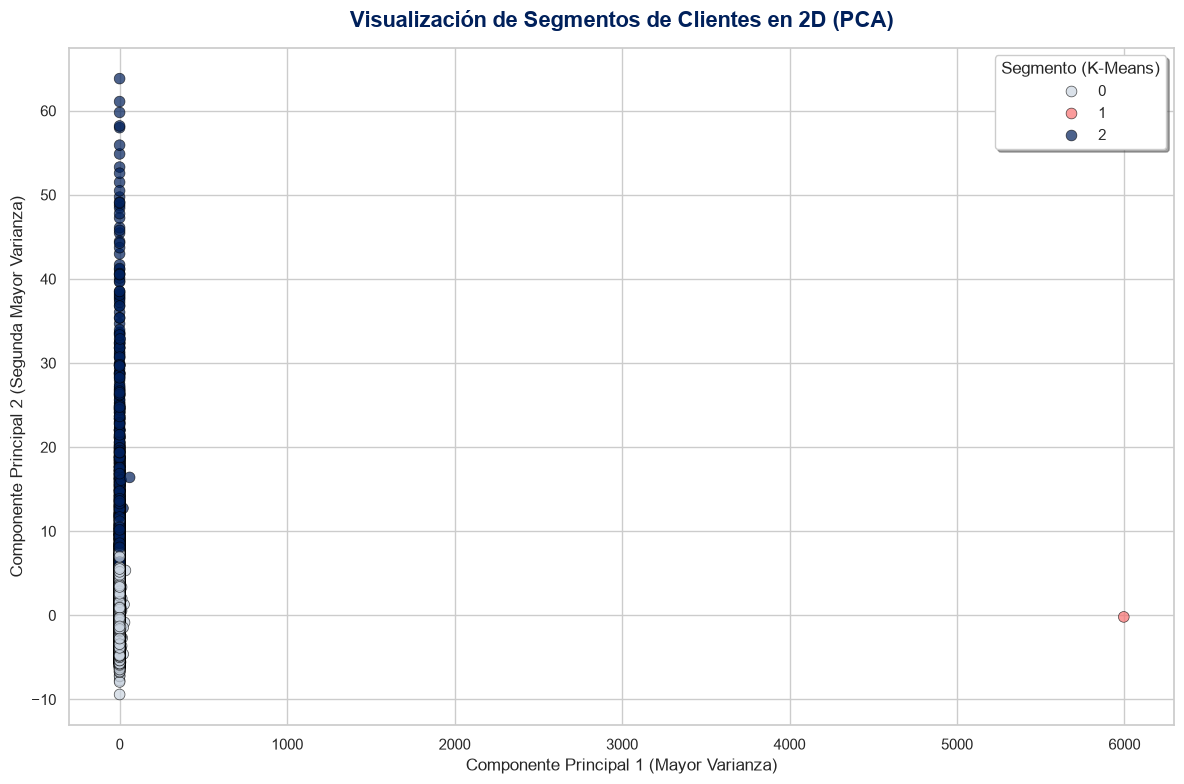

In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Comprimiendo 577 dimensiones a 2D usando PCA...")

# 1. Aplicar PCA para reducir a 2 dimensiones
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_test_prep)

# 2. Crear un DataFrame temporal para facilitar el gráfico
df_pca = pd.DataFrame(data=X_pca, columns=['Componente_Principal_1', 'Componente_Principal_2'])
# Usamos las etiquetas (0, 1, 2) que ya generó nuestro K-Means
df_pca['Segmento'] = etiquetas_clusters 

# 3. Configurar el gráfico de dispersión (Scatter Plot)
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Dibujar los puntos
scatter = sns.scatterplot(
    x='Componente_Principal_1', 
    y='Componente_Principal_2',
    hue='Segmento',
    palette=['#cbd5e1', '#f87171', '#00205B'], # Gris (Masivo), Rojo (Anomalía), Azul (Preferencial)
    data=df_pca,
    alpha=0.7,
    s=60,
    edgecolor='black',
    linewidth=0.5
)

# Estética profesional
plt.title('Visualización de Segmentos de Clientes en 2D (PCA)', fontsize=16, fontweight='bold', color='#00205B', pad=15)
plt.xlabel('Componente Principal 1 (Mayor Varianza)', fontsize=12)
plt.ylabel('Componente Principal 2 (Segunda Mayor Varianza)', fontsize=12)

# Resaltar la Anomalía (Segmento 1) con una flecha si es necesario
# Como sabemos que hay 1 solo cliente, el punto rojo destacará de inmediato.
plt.legend(title='Segmento (K-Means)', title_fontsize='12', fontsize='11', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

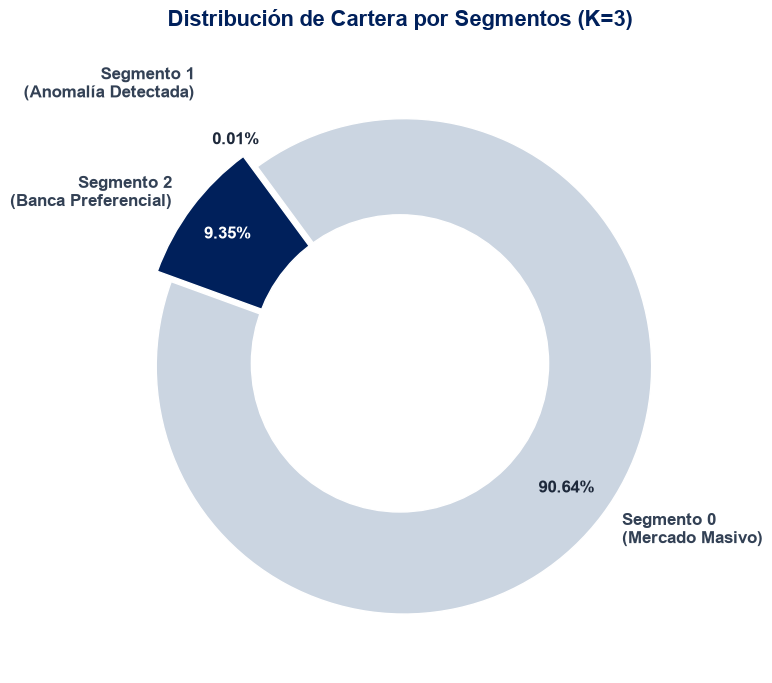

In [24]:
import matplotlib.pyplot as plt

# 1. Definir los datos reales de tus clusters
etiquetas = [
    'Segmento 0\n(Mercado Masivo)', 
    'Segmento 1\n(Anomalía Detectada)', 
    'Segmento 2\n(Banca Preferencial)'
]
volumenes = [9268, 1, 956]

# Paleta de colores: Gris (Masivo), Rojo (Anomalía), Azul (Preferencial)
colores = ['#cbd5e1', '#f87171', '#00205B'] 

# 'explode' sirve para separar los trozos del centro y darle un efecto 3D/Destacado
separacion = (0.02, 0.3, 0.05) 

# 2. Configurar la figura
fig, ax = plt.subplots(figsize=(10, 7))

# 3. Crear el gráfico de torta
wedges, texts, autotexts = ax.pie(
    volumenes, 
    explode=separacion, 
    labels=etiquetas, 
    colors=colores, 
    autopct='%1.2f%%', # Muestra 2 decimales para que el 0.01% de la anomalía sea visible
    startangle=160,    # Gira el gráfico para mejor estética
    pctdistance=0.82,  # Aleja los porcentajes del centro
    textprops={'fontsize': 12, 'fontweight': 'bold', 'color': '#334155'}
)

# 4. TRUCO PRO: Transformar la torta en un gráfico de "Anillo" (Donut)
centro_blanco = plt.Circle((0,0), 0.60, fc='white')
fig.gca().add_artist(centro_blanco)

# 5. Ajustar estética de los textos de porcentaje
for i, autotext in enumerate(autotexts):
    # Poner el porcentaje del segmento preferencial en blanco para que contraste con el azul oscuro
    if i == 2: 
        autotext.set_color('white')
    else:
        autotext.set_color('#1e293b')

# 6. Título profesional
plt.title('Distribución de Cartera por Segmentos (K=3)', fontsize=16, fontweight='bold', color='#00205B', pad=20)

plt.tight_layout()
plt.show()